In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("cars.csv")

In [3]:
df.head()

,Id,year,brand,full_model_name,model_name,price,distance_travelled(kms),fuel_type,city,brand_rank,car_age
0,0,2016,Honda,Honda Brio S MT,Brio,425000.0,9680.0,Petrol,Mumbai,7,5.0
1,1,2012,Nissan,Nissan Sunny XV Diesel,Sunny,325000.0,119120.0,Diesel,Mumbai,11,9.0
2,2,2017,Toyota,Toyota Fortuner 2.8 4x2 MT [2016-2020],Fortuner,2650000.0,64593.0,Diesel,Thane,1,4.0
3,3,2017,Mercedes-Benz,Mercedes-Benz E-Class E 220d Expression [2019-...,E-Class,4195000.0,25000.0,Diesel,Mumbai,2,4.0
4,4,2012,Hyundai,Hyundai Verna Fluidic 1.6 CRDi SX,Verna,475000.0,23800.0,Diesel,Mumbai,14,9.0


In [4]:
df.tail()

,Id,year,brand,full_model_name,model_name,price,distance_travelled(kms),fuel_type,city,brand_rank,car_age
1720,1720,2015,Hyundai,Hyundai Eon Era +,Eon,290000.0,38000.0,Petrol,Pune,14,6.0
1721,1721,2011,Bentley,Bentley Continental Flying Spur W12,Continental,7500000.0,36000.0,Petrol,Pune,44,10.0
1722,1722,2008,Mahindra-Renault,Mahindra-Renault Logan DLE 1.5 dci,Logan,185000.0,142522.0,Diesel,Pune,24,13.0
1723,1723,1990,Mahindra,Mahindra Jeep CJ 500 D,Jeep,325000.0,18581.0,Diesel,Pune,24,31.0
1724,1724,2017,Hyundai,Hyundai Creta SX Plus 1.6 AT CRDI,Creta,1395000.0,31028.0,Diesel,Pune,14,4.0


In [5]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1725
Columns : 11


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1725 entries, 0 to 1724
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Id                       1725 non-null   int64  
 1   year                     1725 non-null   int64  
 2   brand                    1725 non-null   object 
 3   full_model_name          1725 non-null   object 
 4   model_name               1725 non-null   object 
 5   price                    1725 non-null   float64
 6   distance_travelled(kms)  1725 non-null   float64
 7   fuel_type                1725 non-null   object 
 8   city                     1725 non-null   object 
 9   brand_rank               1725 non-null   int64  
 10  car_age                  1725 non-null   float64
dtypes: float64(3), int64(3), object(5)
memory usage: 148.4+ KB


In [7]:
df.describe()

,Id,year,price,distance_travelled(kms),brand_rank,car_age
count,1725.000000,1725.000000,1.725000e+03,1725.000000,1725.000000,1725.000000
mean,862.000000,2015.390725,1.494837e+06,53848.256232,15.731014,5.609275
std,498.108924,3.207504,1.671658e+06,44725.541963,12.951122,3.207504
min,0.000000,1990.000000,6.250000e+04,350.000000,1.000000,0.000000
25%,431.000000,2013.000000,5.450000e+05,29000.000000,5.000000,3.000000
50%,862.000000,2016.000000,8.750000e+05,49000.000000,14.000000,5.000000
75%,1293.000000,2018.000000,1.825000e+06,70500.000000,24.000000,8.000000
max,1724.000000,2021.000000,1.470000e+07,790000.000000,81.000000,31.000000


In [8]:
df.isnull().sum()

Id                         0
year                       0
brand                      0
full_model_name            0
model_name                 0
price                      0
distance_travelled(kms)    0
fuel_type                  0
city                       0
brand_rank                 0
car_age                    0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df = df.drop_duplicates()

In [11]:
df.drop("Id", axis=1, inplace=True)

In [12]:
df.dtypes

year                         int64
brand                       object
full_model_name             object
model_name                  object
price                      float64
distance_travelled(kms)    float64
fuel_type                   object
city                        object
brand_rank                   int64
car_age                    float64
dtype: object

In [13]:
df.to_csv("cleaned_cars.csv", index=False)

## STEP 2

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,5)

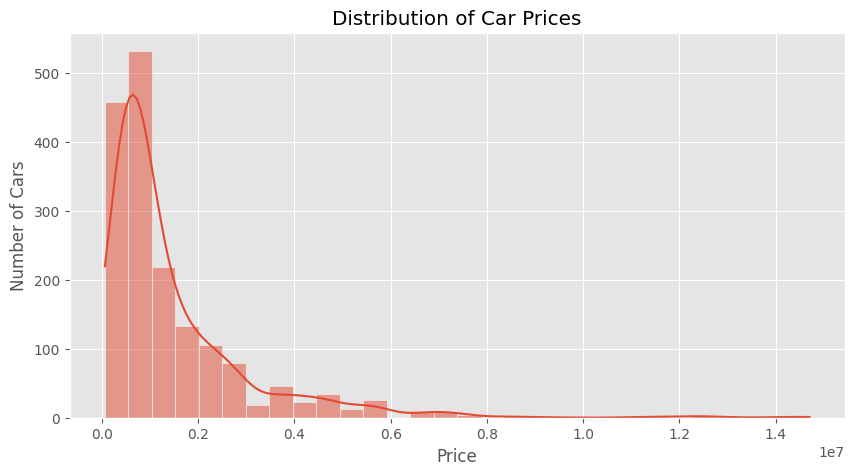

In [15]:
plt.figure(figsize=(10,5))
sns.histplot(df["price"], bins=30, kde=True)
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Number of Cars")
plt.show()

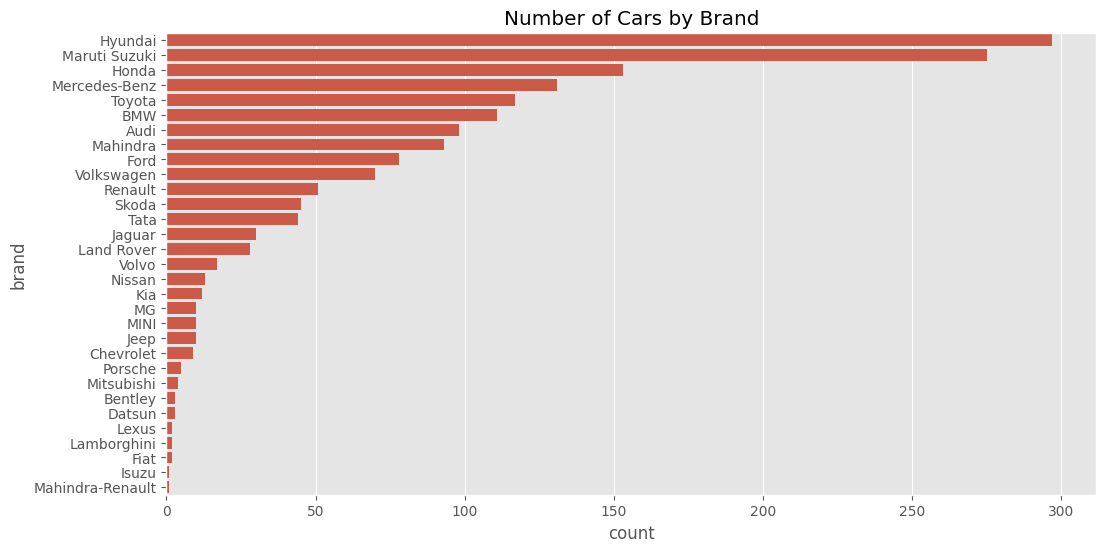

In [16]:
plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    y="brand",
    order=df["brand"].value_counts().index
)

plt.title("Number of Cars by Brand")
plt.show()

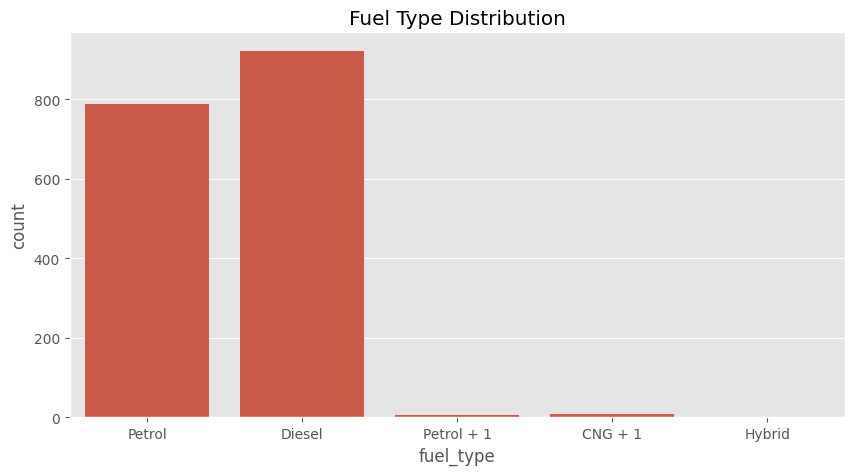

In [17]:
sns.countplot(data=df, x="fuel_type")
plt.title("Fuel Type Distribution")
plt.show()

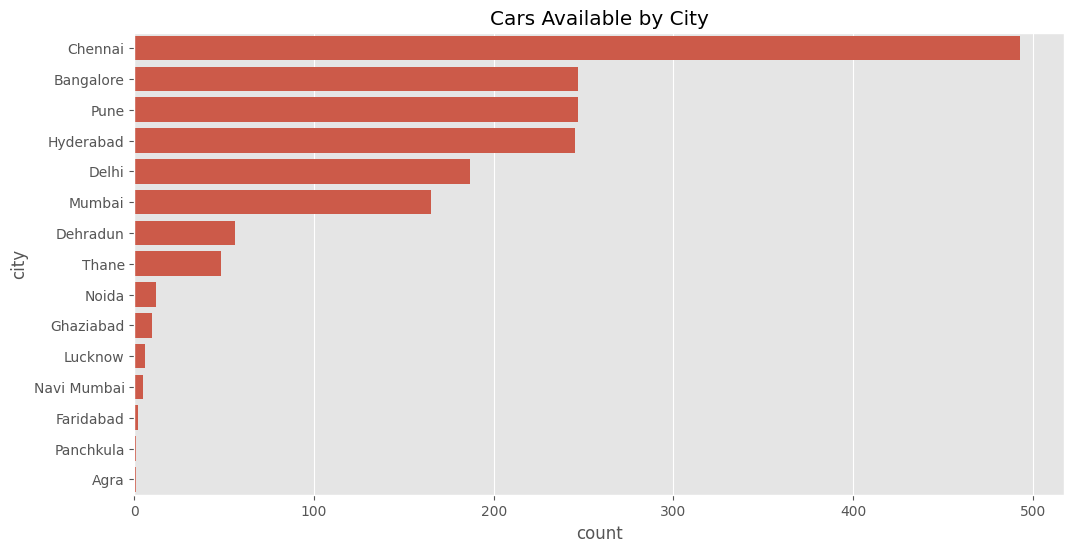

In [18]:
plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    y="city",
    order=df["city"].value_counts().index
)

plt.title("Cars Available by City")
plt.show()

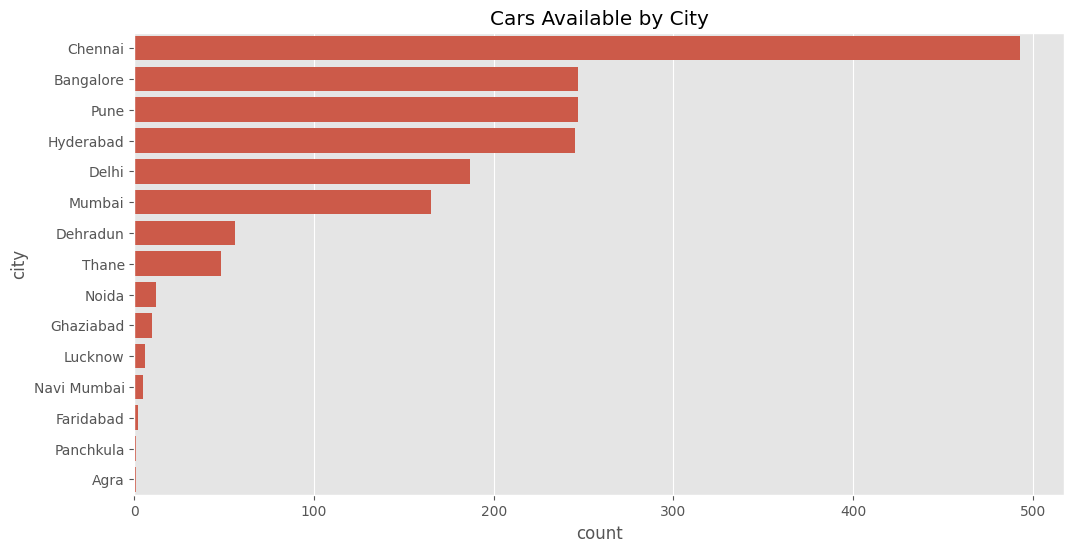

In [19]:
plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    y="city",
    order=df["city"].value_counts().index
)

plt.title("Cars Available by City")
plt.show()

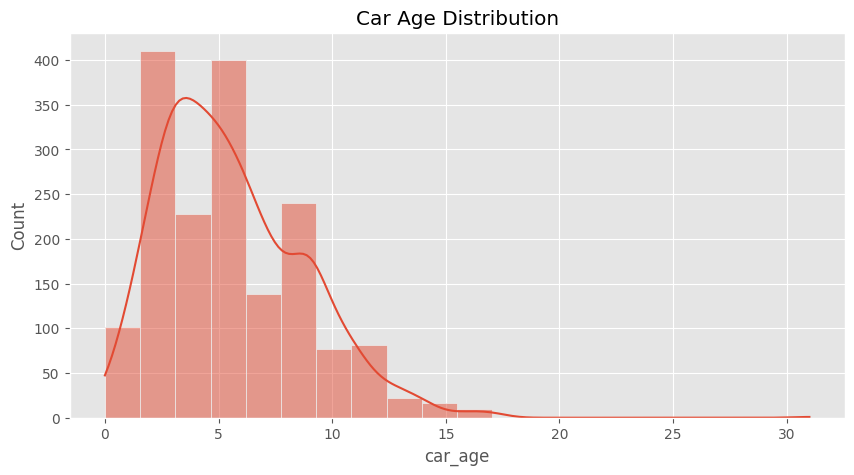

In [20]:
sns.histplot(df["car_age"], bins=20, kde=True)
plt.title("Car Age Distribution")
plt.show()

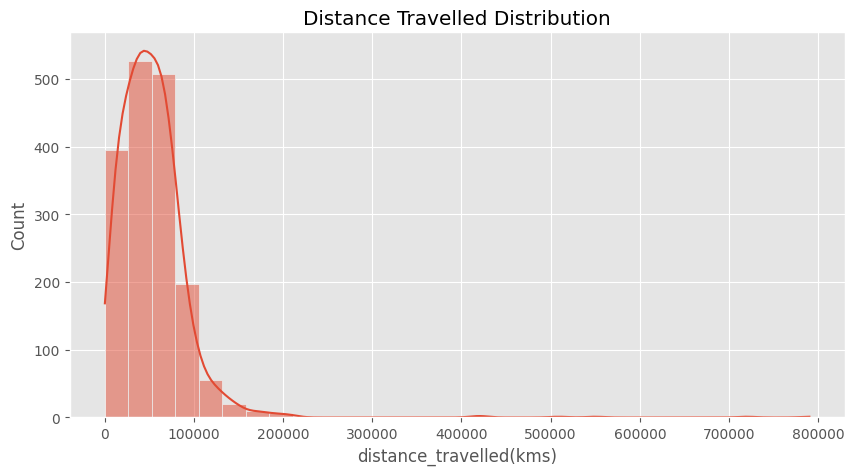

In [21]:
sns.histplot(df["distance_travelled(kms)"], bins=30, kde=True)
plt.title("Distance Travelled Distribution")
plt.show()

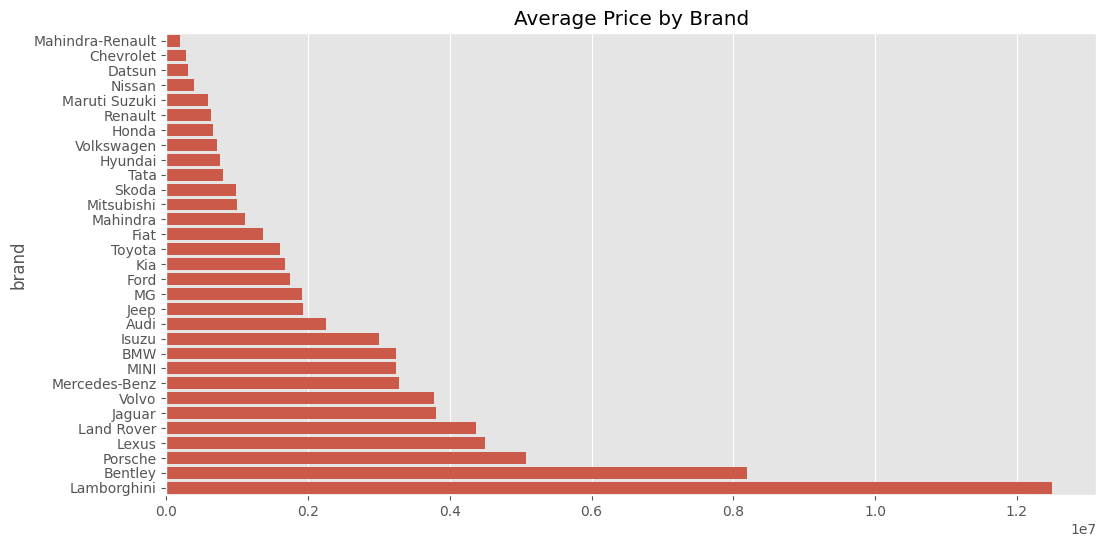

In [22]:
plt.figure(figsize=(12,6))

brand_price = df.groupby("brand")["price"].mean().sort_values()

sns.barplot(
    x=brand_price.values,
    y=brand_price.index
)

plt.title("Average Price by Brand")
plt.show()

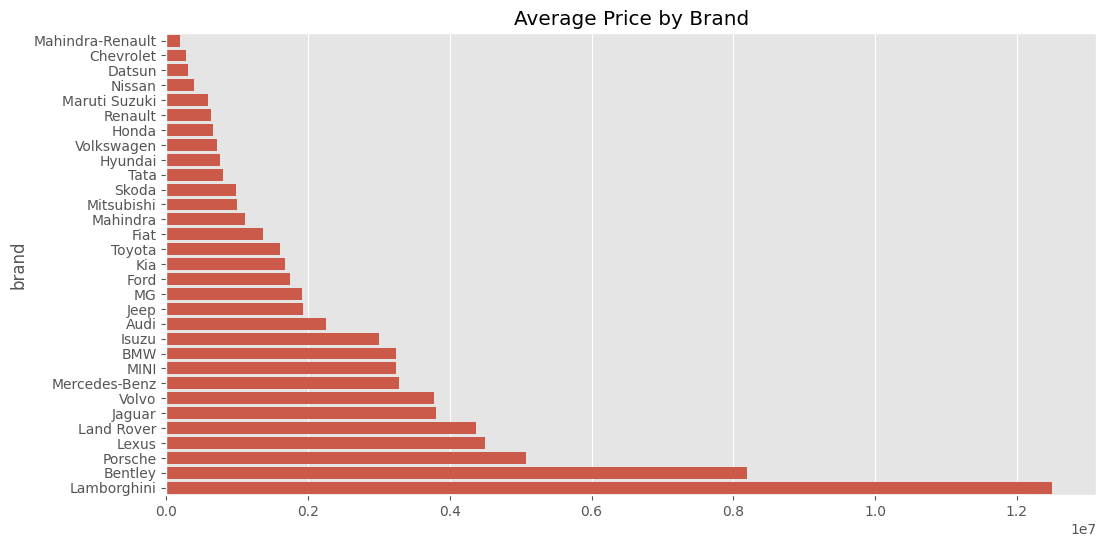

In [23]:
plt.figure(figsize=(12,6))

brand_price = df.groupby("brand")["price"].mean().sort_values()

sns.barplot(
    x=brand_price.values,
    y=brand_price.index
)

plt.title("Average Price by Brand")
plt.show()

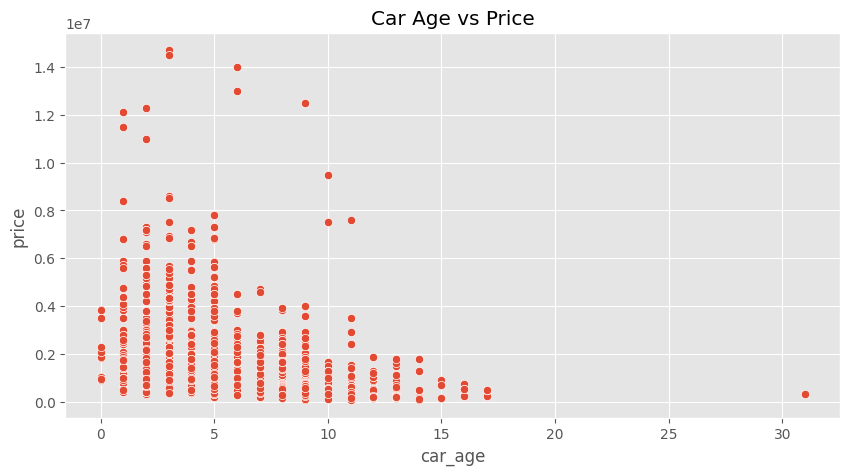

In [24]:
sns.scatterplot(
    data=df,
    x="car_age",
    y="price"
)

plt.title("Car Age vs Price")
plt.show()

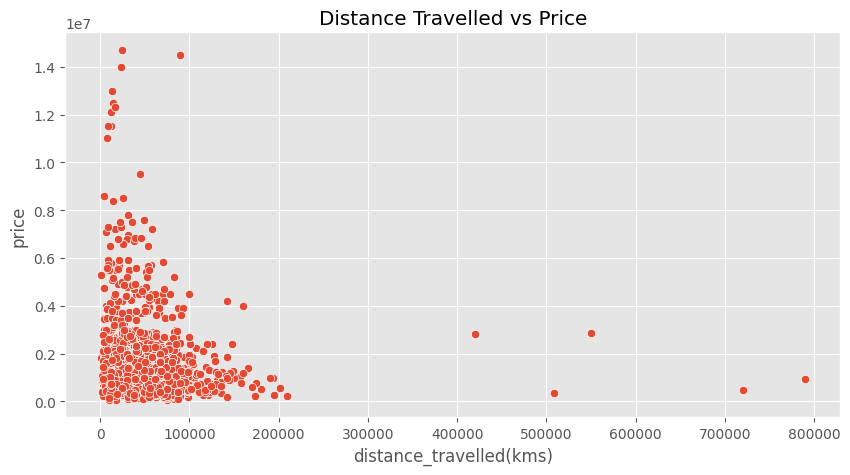

In [25]:
sns.scatterplot(
    data=df,
    x="distance_travelled(kms)",
    y="price"
)

plt.title("Distance Travelled vs Price")
plt.show()

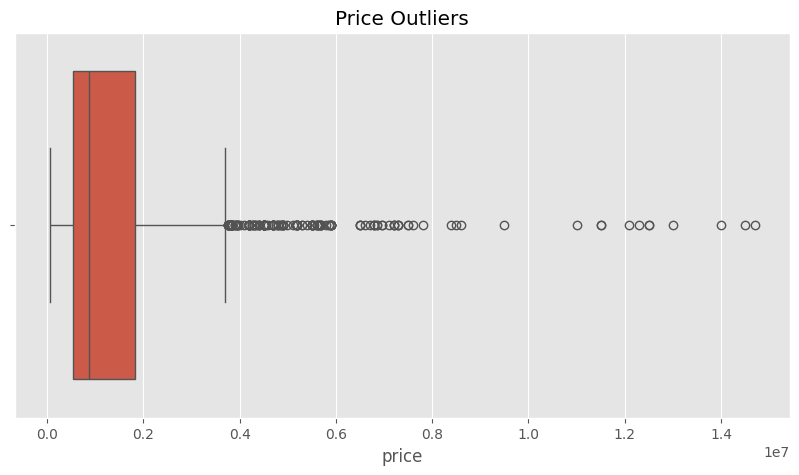

In [26]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["price"])

plt.title("Price Outliers")
plt.show()

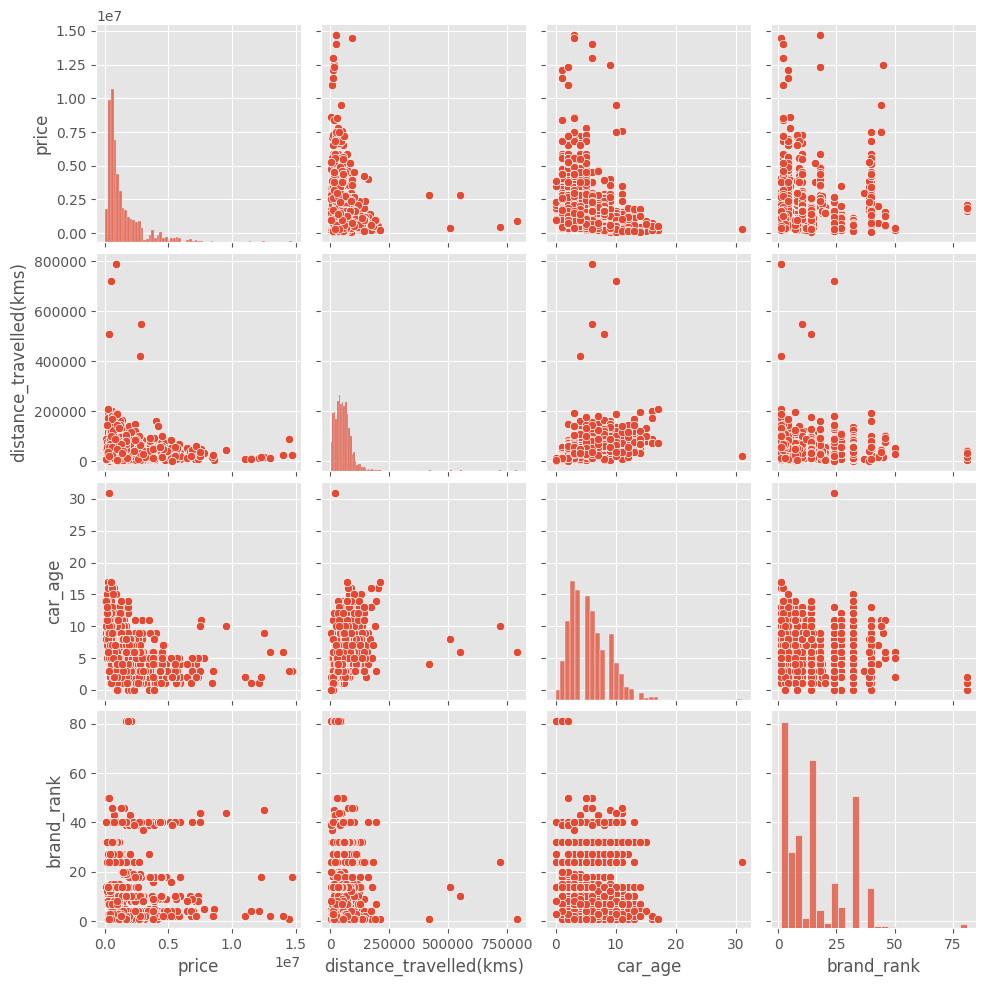

In [27]:
sns.pairplot(
    df[
        [
            "price",
            "distance_travelled(kms)",
            "car_age",
            "brand_rank"
        ]
    ]
)

plt.show()

## STEP 3

In [28]:
df_ml = df.copy()

In [29]:
for column in df_ml.columns:
    print(f"\n{column}")
    print(df_ml[column].unique())


year
[2016 2012 2017 2019 2018 2015 2010 2013 2014 2020 2009 2006 2021 2008
 2011 2007 2005 2004 1990]

brand
['Honda' 'Nissan' 'Toyota' 'Mercedes-Benz' 'Hyundai' 'Maruti Suzuki'
 'Renault' 'Volkswagen' 'Skoda' 'BMW' 'Tata' 'Audi' 'Bentley' 'Ford'
 'Mahindra' 'Jaguar' 'Lamborghini' 'MINI' 'Land Rover' 'Chevrolet'
 'Datsun' 'Jeep' 'Porsche' 'Volvo' 'MG' 'Lexus' 'Mitsubishi' 'Kia' 'Fiat'
 'Isuzu' 'Mahindra-Renault']

full_model_name
['Honda Brio S MT' 'Nissan Sunny XV Diesel'
 'Toyota Fortuner 2.8 4x2 MT [2016-2020]'
 'Mercedes-Benz E-Class E 220d Expression [2019-2019]'
 'Hyundai Verna Fluidic 1.6 CRDi SX' 'Hyundai i20 Sportz 1.2 BS-IV'
 'Toyota Glanza V' 'Mercedes-Benz GLE 250 d'
 'Hyundai Grand i10 Sportz (O) AT 1.2 Kappa VTVT [2017-2018]'
 'Maruti Suzuki Swift Dzire ZXI' 'Hyundai Xcent SX 1.2 (O)'
 'Toyota Innova Crysta 2.4 G 7 STR [2016-2017]'
 'Maruti Suzuki Baleno Alpha 1.2' 'Renault Pulse RxL Petrol [2015-2017]'
 'Maruti Suzuki Baleno Zeta 1.2 AT' 'Hyundai Xcent S AT 1.2 (O)'
 '

In [30]:
df_ml.nunique().sort_values(ascending=False)

full_model_name            750
distance_travelled(kms)    649
price                      404
model_name                 169
brand                       31
brand_rank                  29
year                        19
car_age                     19
city                        15
fuel_type                    5
dtype: int64

In [31]:
df_ml.drop("full_model_name", axis=1, inplace=True)

In [32]:
df_ml.head()

,year,brand,model_name,price,distance_travelled(kms),fuel_type,city,brand_rank,car_age
0,2016,Honda,Brio,425000.0,9680.0,Petrol,Mumbai,7,5.0
1,2012,Nissan,Sunny,325000.0,119120.0,Diesel,Mumbai,11,9.0
2,2017,Toyota,Fortuner,2650000.0,64593.0,Diesel,Thane,1,4.0
3,2017,Mercedes-Benz,E-Class,4195000.0,25000.0,Diesel,Mumbai,2,4.0
4,2012,Hyundai,Verna,475000.0,23800.0,Diesel,Mumbai,14,9.0


In [33]:
numerical_columns = df_ml.select_dtypes(include=["int64","float64"]).columns

categorical_columns = df_ml.select_dtypes(include=["object"]).columns

print("Numerical Columns")
print(numerical_columns)

print("\nCategorical Columns")
print(categorical_columns)

Numerical Columns
Index(['year', 'price', 'distance_travelled(kms)', 'brand_rank', 'car_age'], dtype='object')

Categorical Columns
Index(['brand', 'model_name', 'fuel_type', 'city'], dtype='object')


In [34]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in categorical_columns:
    df_ml[column] = le.fit_transform(df_ml[column])

In [35]:
df_ml.head()

,year,brand,model_name,price,distance_travelled(kms),fuel_type,city,brand_rank,car_age
0,2016,7,28,425000.0,9680.0,3,9,7,5.0
1,2012,23,129,325000.0,119120.0,1,9,11,9.0
2,2017,28,69,2650000.0,64593.0,1,14,1,4.0
3,2017,21,51,4195000.0,25000.0,1,9,2,4.0
4,2012,8,144,475000.0,23800.0,1,9,14,9.0


In [36]:
corr = df_ml.corr()

corr["price"].sort_values(ascending=False)

price                      1.000000
year                       0.288483
model_name                -0.082217
city                      -0.082369
brand                     -0.112988
distance_travelled(kms)   -0.137351
brand_rank                -0.164591
fuel_type                 -0.259728
car_age                   -0.288483
Name: price, dtype: float64

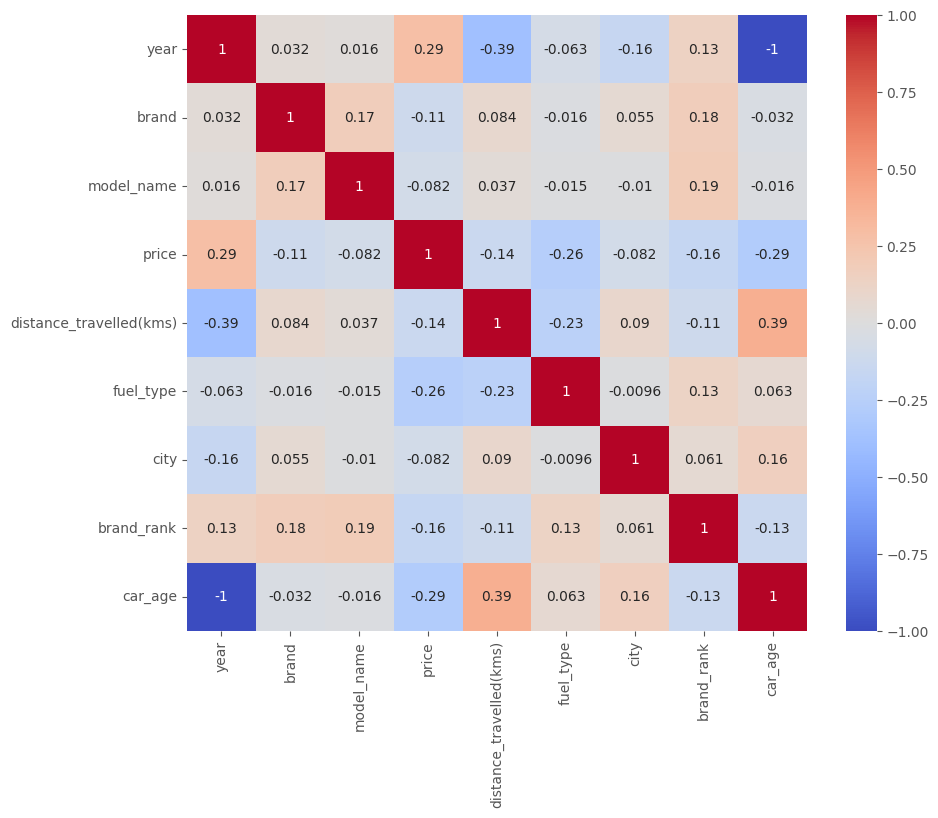

In [37]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [38]:
X = df_ml.drop("price", axis=1)

y = df_ml["price"]

In [39]:
print(X.shape)
print(y.shape)

(1725, 8)
(1725,)


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [41]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (1380, 8)
Testing Features  : (345, 8)
Training Target   : (1380,)
Testing Target    : (345,)


In [42]:
df_ml.to_csv("processed_cars.csv", index=False)

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [44]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [45]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R2 :", lr_r2)

Linear Regression
MAE : 932370.1679799322
RMSE: 1617821.5105580438
R2 : 0.22033494054139535


In [46]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [47]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree")

print("MAE :", dt_mae)
print("RMSE:", dt_rmse)
print("R2 :", dt_r2)

Decision Tree
MAE : 357741.5458937198
RMSE: 1181725.4645265401
R2 : 0.5840127219800202


In [48]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [49]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")

print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2 :", rf_r2)

Random Forest
MAE : 341344.04632505175
RMSE: 985801.8447511322
R2 : 0.7105149675345201


In [50]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE":[
        lr_mae,
        dt_mae,
        rf_mae
    ],

    "RMSE":[
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],

    "R2 Score":[
        lr_r2,
        dt_r2,
        rf_r2
    ]

})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,932370.167980,1.617822e+06,0.220335
1,Decision Tree,357741.545894,1.181725e+06,0.584013
2,Random Forest,341344.046325,9.858018e+05,0.710515


In [51]:
results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
2,Random Forest,341344.046325,9.858018e+05,0.710515
1,Decision Tree,357741.545894,1.181725e+06,0.584013
0,Linear Regression,932370.167980,1.617822e+06,0.220335


In [52]:
importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,brand,0.246615
6,brand_rank,0.230476
2,model_name,0.168333
7,car_age,0.105373
3,distance_travelled(kms),0.102721
0,year,0.096828
5,city,0.028736
4,fuel_type,0.020919


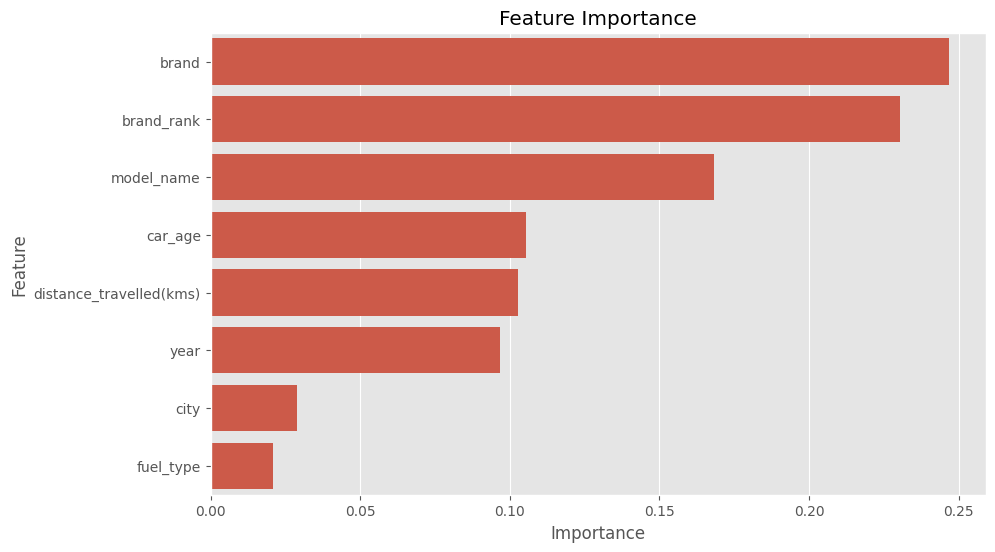

In [53]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

In [54]:
comparison = pd.DataFrame({

    "Actual Price": y_test,
    "Predicted Price": rf_pred

})

comparison.head(20)

,Actual Price,Predicted Price
339,365000.0,4.072000e+05
598,1195000.0,7.087900e+05
300,575000.0,7.132050e+05
1510,900000.0,1.096825e+06
433,1675000.0,1.209050e+06
1293,1050000.0,1.390600e+06
23,675000.0,9.414800e+05
842,2600000.0,2.111000e+06
1422,2400000.0,2.468120e+06
1258,990000.0,1.022700e+06


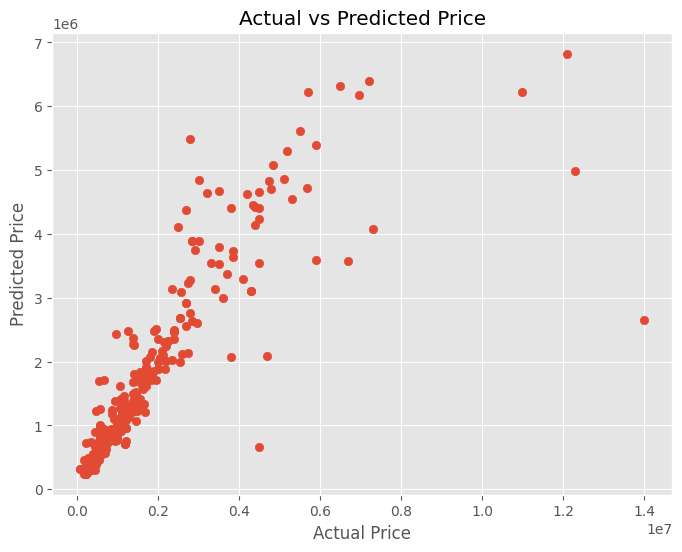

In [55]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()

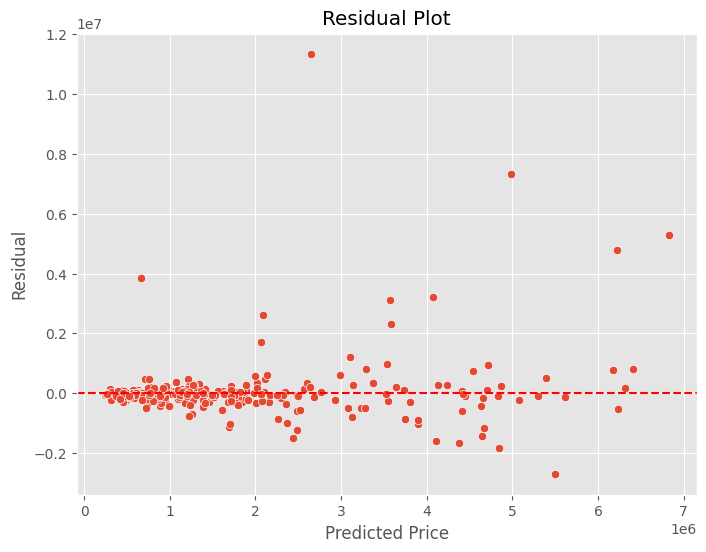

In [56]:
residuals = y_test - rf_pred

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=rf_pred,
    y=residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [57]:
import joblib

joblib.dump(
    rf,
    "best_model.pkl"
)

['best_model.pkl']

In [58]:
df_predictions = df.copy()

df_predictions["Predicted Price"] = rf.predict(X)

In [59]:
df_predictions.to_csv(
    "prediction_dataset.csv",
    index=False
)

In [60]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:", scores)
print("Average R²:", scores.mean())

Cross Validation Scores: [0.47655396 0.56885222 0.62921153 0.934668   0.82659129]
Average R²: 0.6871753994067495


In [61]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='r2')

In [62]:
print(grid.best_params_)

{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [63]:
best_rf = grid.best_estimator_

In [64]:
best_pred = best_rf.predict(X_test)

In [65]:
mae = mean_absolute_error(y_test, best_pred)

rmse = np.sqrt(mean_squared_error(y_test, best_pred))

r2 = r2_score(y_test, best_pred)

print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)

MAE : 340772.53390341497
RMSE : 984728.1229872192
R² : 0.7111452303148909


In [66]:
comparison = pd.DataFrame({

    "Model":[
        "Random Forest",
        "Optimized Random Forest"
    ],

    "R²":[
        rf_r2,
        r2
    ],

    "RMSE":[
        rf_rmse,
        rmse
    ],

    "MAE":[
        rf_mae,
        mae
    ]

})

comparison

,Model,R²,RMSE,MAE
0,Random Forest,0.710515,985801.844751,341344.046325
1,Optimized Random Forest,0.711145,984728.122987,340772.533903


In [67]:
import joblib

joblib.dump(
    best_rf,
    "Final_Car_Price_Model.pkl"
)

['Final_Car_Price_Model.pkl']

In [68]:
df["Predicted Price"] = best_rf.predict(X)

In [69]:
df.to_csv(
    "Final_Car_Price_Prediction.csv",
    index=False
)

In [70]:
importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": best_rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,brand,0.245755
6,brand_rank,0.229099
2,model_name,0.167482
7,car_age,0.107683
3,distance_travelled(kms),0.103433
0,year,0.096974
5,city,0.028578
4,fuel_type,0.020996


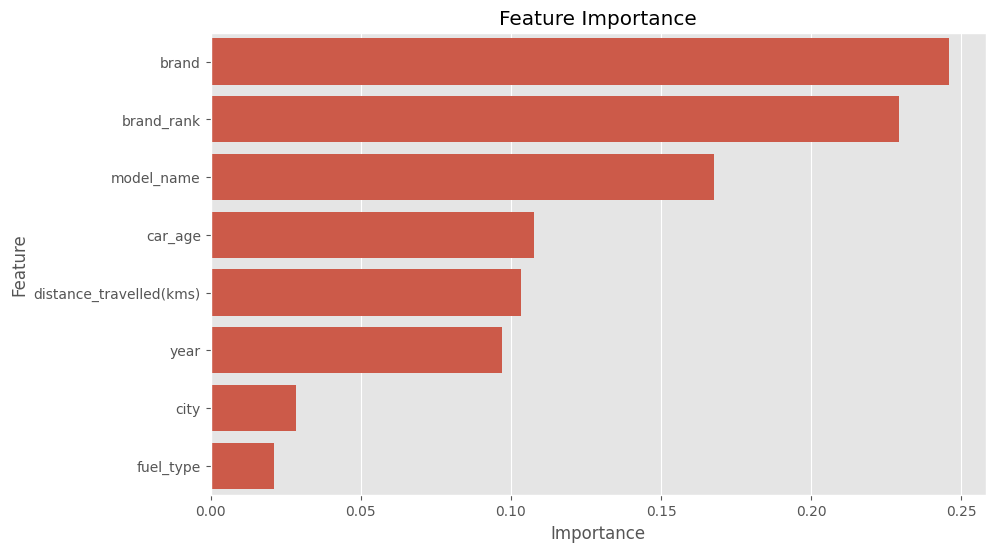

In [71]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

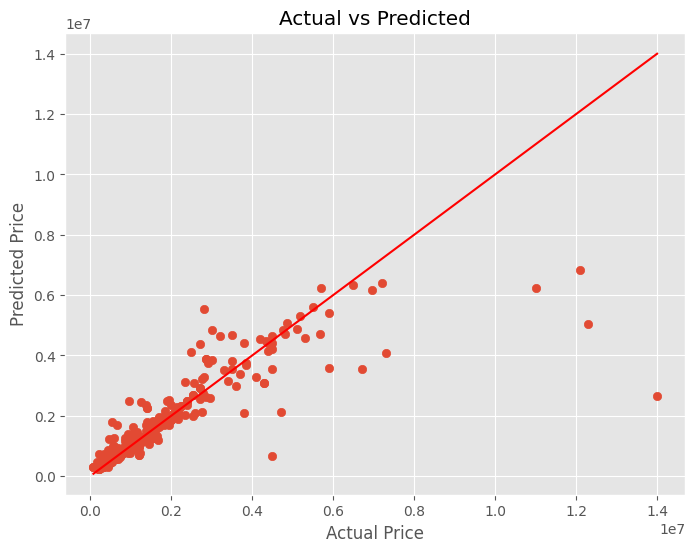

In [72]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, best_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

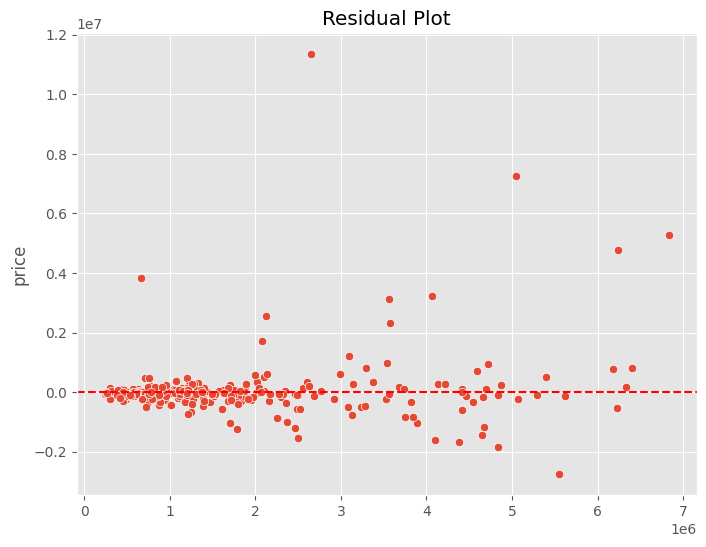

In [73]:
residual = y_test - best_pred

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=best_pred,
    y=residual
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Residual Plot")

plt.show()

In [74]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.to_csv("feature_importance.csv", index=False)

importance.head()

,Feature,Importance
1,brand,0.245755
6,brand_rank,0.229099
2,model_name,0.167482
7,car_age,0.107683
3,distance_travelled(kms),0.103433
